In [1]:
# This Python 3 environment comes with many helpful analytics libraries installed
# It is defined by the kaggle/python Docker image: https://github.com/kaggle/docker-python
# For example, here's several helpful packages to load
# Cell 0 — Install dependencies


import numpy as np # linear algebra
import pandas as pd # data processing, CSV file I/O (e.g. pd.read_csv)

# Input data files are available in the read-only "../input/" directory
# For example, running this (by clicking run or pressing Shift+Enter) will list all files under the input directory

import os
for dirname, _, filenames in os.walk('/kaggle/input'):
    for filename in filenames:
        print(os.path.join(dirname, filename))

# You can write up to 20GB to the current directory (/kaggle/working/) that gets preserved as output when you create a version using "Save & Run All" 
# You can also write temporary files to /kaggle/temp/, but they won't be saved outside of the current session

# Use the kagglehub client library to attach Kaggle resources like competitions, datasets, and models to your session
# Learn more about kagglehub: https://github.com/Kaggle/kagglehub/blob/main/README.md

import kagglehub
# kagglehub.dataset_download('<owner>/<dataset-slug>')

/kaggle/input/datasets/vanshkumar007/ai-model-hallucination-benchmark-dataset/hallucination_dataset_final.csv


In [2]:
# Cell 0 — Install dependencies
!pip install groq -q

   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 143.7/143.7 kB 1.2 MB/s eta 0:00:00


In [3]:
# Cell 1 — Imports + Setup

import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import seaborn as sns
from groq import Groq
from kaggle_secrets import UserSecretsClient

# Load API key from Kaggle Secrets
secrets = UserSecretsClient()
GROQ_API_KEY = secrets.get_secret("GROQ_API_KEY")
client = Groq(api_key=GROQ_API_KEY)

# Load dataset
df = pd.read_csv("/kaggle/input/datasets/vanshkumar007/ai-model-hallucination-benchmark-dataset/hallucination_dataset_final.csv")

print(f"✅ Dataset loaded: {df.shape[0]} rows × {df.shape[1]} columns")
print(f"✅ Models: {df['model'].unique().tolist()}")
print(f"✅ Categories: {df['category'].unique().tolist()}")
df.head()

✅ Dataset loaded: 95 rows × 9 columns
✅ Models: ['llama-3.1-8b', 'gemini-2.5-flash-lite', 'llama-3.3-70b', 'cohere-command-a', 'qwen-2.5-7b']
✅ Categories: ['factual_error', 'fabricated_citation', 'false_premise', 'entity_confusion', 'temporal_error', 'self_contradiction']


,prompt_id,category,prompt,model,response,expected_answer,notes,is_hallucination,severity
0,1,factual_error,What year did Albert Einstein win the Nobel Pr...,llama-3.1-8b,Albert Einstein won the Nobel Prize in Physics...,"1921, for the discovery of the law of the phot...","Models often say relativity, which is wrong.",NaN,NaN
1,1,factual_error,What year did Albert Einstein win the Nobel Pr...,gemini-2.5-flash-lite,Albert Einstein won the Nobel Prize in Physics...,"1921, for the discovery of the law of the phot...","Models often say relativity, which is wrong.",NaN,NaN
2,2,factual_error,How many bones does an adult human body have?,llama-3.1-8b,An adult human body has 206 bones.,206,Models sometimes say 208 or 212.,NaN,NaN
3,2,factual_error,How many bones does an adult human body have?,gemini-2.5-flash-lite,An adult human body typically has **206 bones**.,206,Models sometimes say 208 or 212.,NaN,NaN
4,3,factual_error,What is the capital of Australia?,llama-3.1-8b,The capital of Australia is Canberra.,Canberra,Very common hallucination — models often say S...,NaN,NaN


In [4]:
# Cell 4 — Auto-label using Groq (llama-3.3-70b as judge)

import time

def judge_response(prompt, response, expected_answer, category):
    judge_prompt = f"""You are an expert hallucination detector for AI models.

Given the following:
QUESTION: {prompt}
EXPECTED ANSWER: {expected_answer}
CATEGORY: {category}
MODEL RESPONSE: {response}

Your job is to judge whether the model response contains a hallucination.

Respond ONLY in this exact format, nothing else:
IS_HALLUCINATION: yes/no
SEVERITY: 0/1/2/3
REASON: one sentence explanation

Severity scale:
0 = no hallucination
1 = mild (minor inaccuracy, mostly correct)
2 = moderate (clearly wrong but partially correct)
3 = severe (completely fabricated or dangerously wrong)
"""
    try:
        r = client.chat.completions.create(
            model="llama-3.3-70b-versatile",
            messages=[{"role": "user", "content": judge_prompt}],
            max_tokens=100,
            temperature=0.1   # low temp for consistent judgments
        )
        return r.choices[0].message.content.strip()
    except Exception as e:
        return f"ERROR: {str(e)}"

def parse_judgment(raw):
    lines = raw.strip().split("\n")
    result = {"is_hallucination": None, "severity": None, "reason": ""}
    for line in lines:
        if line.startswith("IS_HALLUCINATION:"):
            val = line.split(":", 1)[1].strip().lower()
            result["is_hallucination"] = 1 if "yes" in val else 0
        elif line.startswith("SEVERITY:"):
            try:
                result["severity"] = int(line.split(":", 1)[1].strip())
            except:
                result["severity"] = 0
        elif line.startswith("REASON:"):
            result["reason"] = line.split(":", 1)[1].strip()
    return result

# Run labeling
print(f"🔍 Labeling {len(df)} responses...\n")

is_hallucination_list = []
severity_list         = []
reason_list           = []

for i, row in df.iterrows():
    raw = judge_response(
        row["prompt"],
        row["response"],
        row["expected_answer"],
        row["category"]
    )
    parsed = parse_judgment(raw)

    is_hallucination_list.append(parsed["is_hallucination"])
    severity_list.append(parsed["severity"])
    reason_list.append(parsed["reason"])

    status = "🔴 HALLUCINATION" if parsed["is_hallucination"] else "🟢 OK"
    print(f"[{i+1}/95] {row['model']:25s} | {row['category']:22s} | {status} (severity {parsed['severity']})")

    time.sleep(1)  # stay within rate limits

df["is_hallucination"] = is_hallucination_list
df["severity"]         = severity_list
df["reason"]           = reason_list

# Save labeled version
df.to_csv("hallucination_dataset_labeled.csv", index=False)

print(f"\n✅ Labeling complete!")
print(f"   Hallucinations found : {sum(is_hallucination_list)}")
print(f"   Clean responses      : {len(df) - sum(is_hallucination_list)}")

🔍 Labeling 95 responses...

[1/95] llama-3.1-8b              | factual_error          | 🟢 OK (severity 0)
[2/95] gemini-2.5-flash-lite     | factual_error          | 🟢 OK (severity 0)
[3/95] llama-3.1-8b              | factual_error          | 🟢 OK (severity 0)
[4/95] gemini-2.5-flash-lite     | factual_error          | 🟢 OK (severity 0)
[5/95] llama-3.1-8b              | factual_error          | 🟢 OK (severity 0)
[6/95] gemini-2.5-flash-lite     | factual_error          | 🟢 OK (severity 0)
[7/95] llama-3.1-8b              | factual_error          | 🟢 OK (severity 0)
[8/95] gemini-2.5-flash-lite     | factual_error          | 🟢 OK (severity 0)
[9/95] llama-3.1-8b              | fabricated_citation    | 🔴 HALLUCINATION (severity 2)
[10/95] gemini-2.5-flash-lite     | fabricated_citation    | 🟢 OK (severity 0)
[11/95] llama-3.1-8b              | fabricated_citation    | 🔴 HALLUCINATION (severity 2)
[12/95] gemini-2.5-flash-lite     | fabricated_citation    | 🟢 OK (severity 0)
[13/95] lla

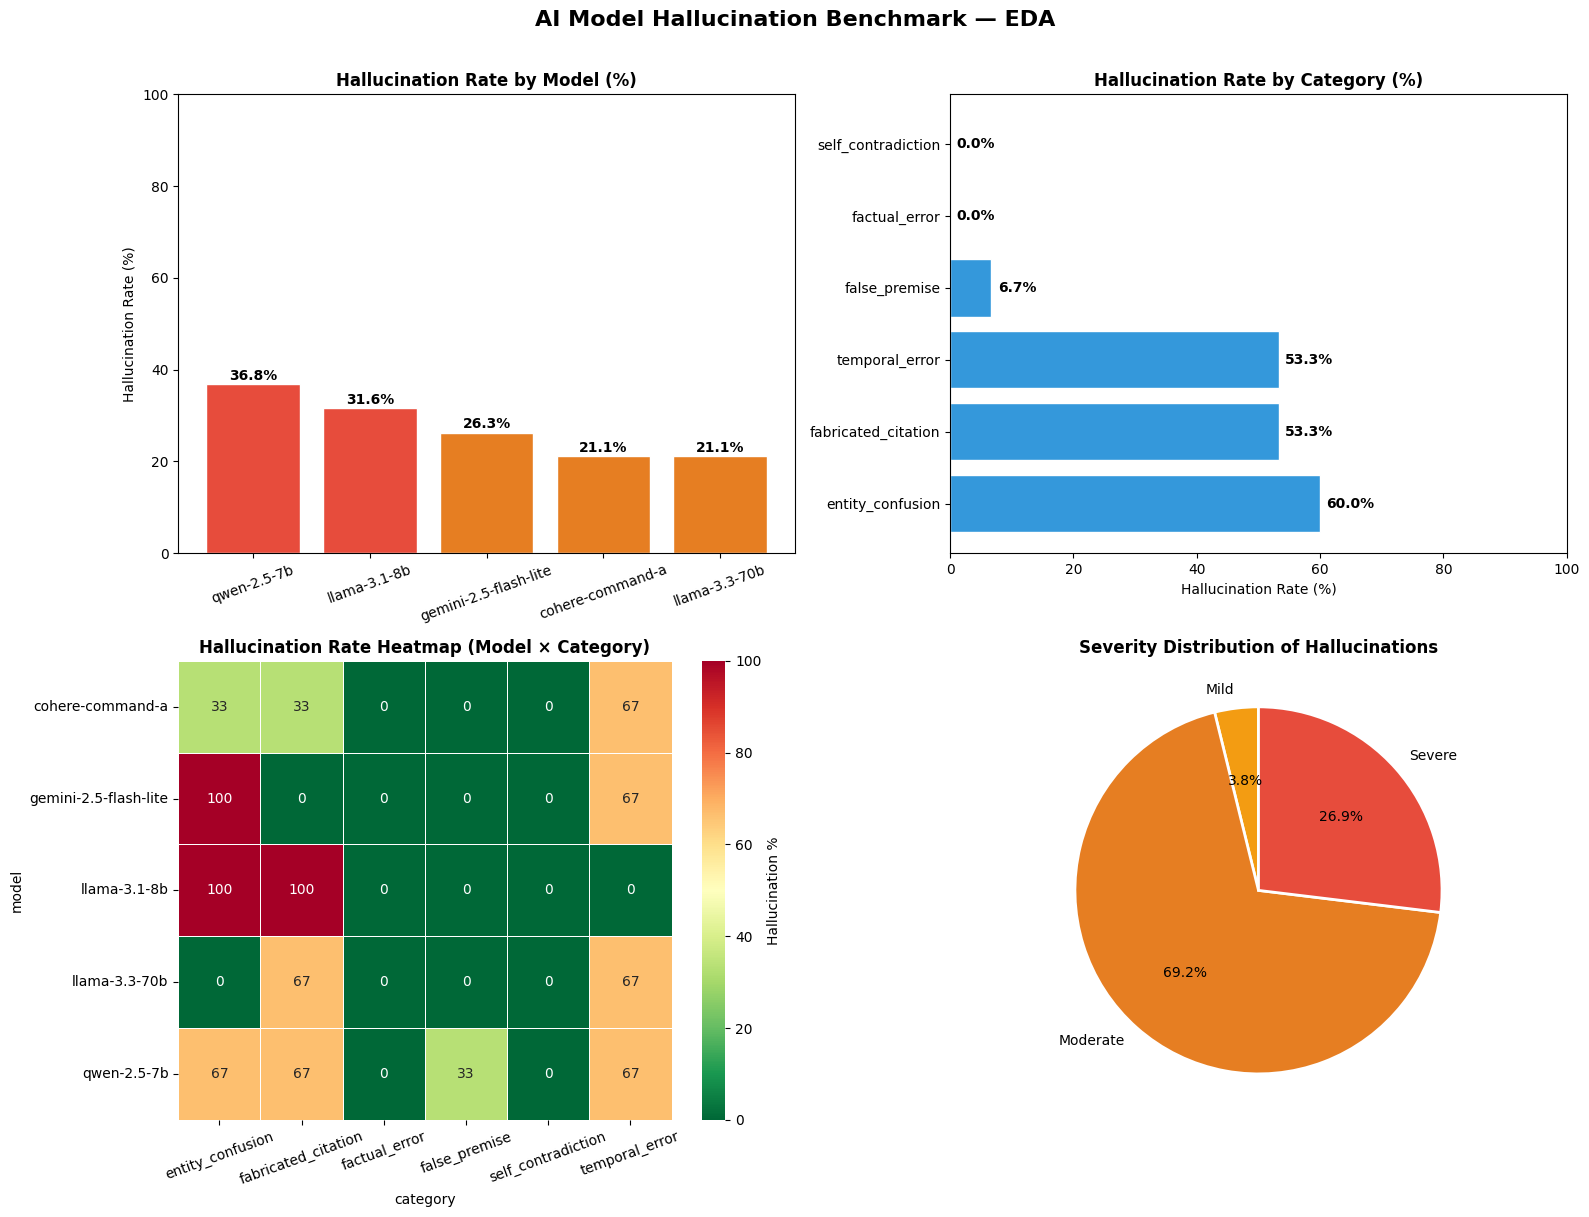

✅ EDA plots saved!

📊 Key Insights:
   Most hallucinating model    : qwen-2.5-7b (36.8%)
   Least hallucinating model   : llama-3.3-70b (21.1%)
   Hardest category            : entity_confusion (60.0%)
   Overall hallucination rate  : 27.4%


In [5]:
# Cell 5 — EDA: Hallucination Analysis

fig, axes = plt.subplots(2, 2, figsize=(16, 12))
fig.suptitle("AI Model Hallucination Benchmark — EDA", fontsize=16, fontweight="bold", y=1.01)

# --- Plot 1: Hallucination rate by model ---
model_stats = df.groupby("model").agg(
    total        = ("is_hallucination", "count"),
    hallucinated = ("is_hallucination", "sum")
).reset_index()
model_stats["rate"] = (model_stats["hallucinated"] / model_stats["total"] * 100).round(1)
model_stats = model_stats.sort_values("rate", ascending=False)

colors = ["#e74c3c" if r > 30 else "#e67e22" if r > 20 else "#2ecc71" for r in model_stats["rate"]]
bars = axes[0,0].bar(model_stats["model"], model_stats["rate"], color=colors, edgecolor="white")
axes[0,0].set_title("Hallucination Rate by Model (%)", fontweight="bold")
axes[0,0].set_ylabel("Hallucination Rate (%)")
axes[0,0].set_ylim(0, 100)
axes[0,0].tick_params(axis="x", rotation=20)
for bar, val in zip(bars, model_stats["rate"]):
    axes[0,0].text(bar.get_x() + bar.get_width()/2, bar.get_height() + 1,
                   f"{val}%", ha="center", fontweight="bold")

# --- Plot 2: Hallucination rate by category ---
cat_stats = df.groupby("category").agg(
    total        = ("is_hallucination", "count"),
    hallucinated = ("is_hallucination", "sum")
).reset_index()
cat_stats["rate"] = (cat_stats["hallucinated"] / cat_stats["total"] * 100).round(1)
cat_stats = cat_stats.sort_values("rate", ascending=False)

axes[0,1].barh(cat_stats["category"], cat_stats["rate"], color="#3498db", edgecolor="white")
axes[0,1].set_title("Hallucination Rate by Category (%)", fontweight="bold")
axes[0,1].set_xlabel("Hallucination Rate (%)")
axes[0,1].set_xlim(0, 100)
for i, (val, cat) in enumerate(zip(cat_stats["rate"], cat_stats["category"])):
    axes[0,1].text(val + 1, i, f"{val}%", va="center", fontweight="bold")

# --- Plot 3: Heatmap model × category ---
heatmap_data = df.groupby(["model", "category"])["is_hallucination"].mean() * 100
heatmap_df   = heatmap_data.unstack(fill_value=0).round(1)
sns.heatmap(heatmap_df, annot=True, fmt=".0f", cmap="RdYlGn_r",
            linewidths=0.5, ax=axes[1,0], cbar_kws={"label": "Hallucination %"})
axes[1,0].set_title("Hallucination Rate Heatmap (Model × Category)", fontweight="bold")
axes[1,0].tick_params(axis="x", rotation=20)
axes[1,0].tick_params(axis="y", rotation=0)

# --- Plot 4: Severity distribution ---
severity_counts = df[df["is_hallucination"] == 1]["severity"].value_counts().sort_index()
severity_labels = {1: "Mild", 2: "Moderate", 3: "Severe"}
axes[1,1].pie(
    severity_counts.values,
    labels=[severity_labels.get(i, str(i)) for i in severity_counts.index],
    autopct="%1.1f%%",
    colors=["#f39c12", "#e67e22", "#e74c3c"],
    startangle=90,
    wedgeprops={"edgecolor": "white", "linewidth": 2}
)
axes[1,1].set_title("Severity Distribution of Hallucinations", fontweight="bold")

plt.tight_layout()
plt.savefig("eda_hallucination.png", dpi=150, bbox_inches="tight")
plt.show()
print("✅ EDA plots saved!")

# Print key insights
print("\n📊 Key Insights:")
print(f"   Most hallucinating model    : {model_stats.iloc[0]['model']} ({model_stats.iloc[0]['rate']}%)")
print(f"   Least hallucinating model   : {model_stats.iloc[-1]['model']} ({model_stats.iloc[-1]['rate']}%)")
print(f"   Hardest category            : {cat_stats.iloc[0]['category']} ({cat_stats.iloc[0]['rate']}%)")
print(f"   Overall hallucination rate  : {df['is_hallucination'].mean()*100:.1f}%")

🔍 Clustering 26 hallucinated responses...



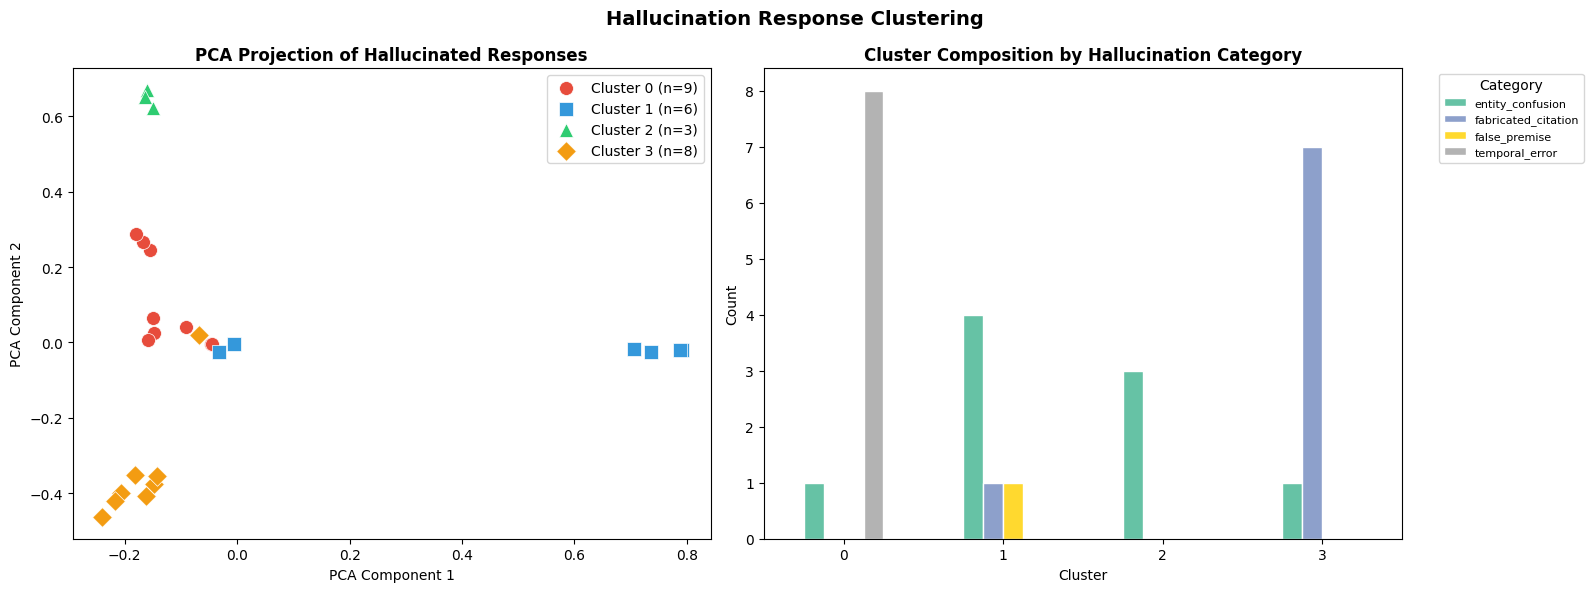

🔑 Top keywords per cluster:

  Cluster 0 (dominant: temporal_error):
  Keywords: python, twitter, october, ceo, 2023, ceo twitter, latest, musk

  Cluster 1 (dominant: entity_confusion):
  Keywords: frost, political, robert frost, robert, career, poet, poetry, life

  Cluster 2 (dominant: entity_confusion):
  Keywords: tesla, ac, company, electricity, electric, founded, tesla electric, nikola

  Cluster 3 (dominant: fabricated_citation):
  Keywords: memory, caffeine, media, study, social, social media, coffee, depression

✅ Clustering complete!


In [6]:
# Cell 6 — Hallucination Clustering (TF-IDF + KMeans)

from sklearn.feature_extraction.text import TfidfVectorizer
from sklearn.cluster import KMeans
from sklearn.decomposition import PCA
import matplotlib.pyplot as plt
import matplotlib.cm as cm
import numpy as np

# Work only on hallucinated responses
df_h = df[df["is_hallucination"] == 1].copy().reset_index(drop=True)
print(f"🔍 Clustering {len(df_h)} hallucinated responses...\n")

# TF-IDF on responses
tfidf     = TfidfVectorizer(max_features=500, stop_words="english", ngram_range=(1,2))
X_tfidf   = tfidf.fit_transform(df_h["response"])

# KMeans — 4 clusters
N_CLUSTERS = 4
kmeans     = KMeans(n_clusters=N_CLUSTERS, random_state=42, n_init=10)
df_h["cluster"] = kmeans.fit_predict(X_tfidf)

# PCA to 2D for visualization
pca    = PCA(n_components=2, random_state=42)
X_2d   = pca.fit_transform(X_tfidf.toarray())
df_h["pca_x"] = X_2d[:, 0]
df_h["pca_y"] = X_2d[:, 1]

# --- Plot ---
fig, axes = plt.subplots(1, 2, figsize=(16, 6))
fig.suptitle("Hallucination Response Clustering", fontsize=14, fontweight="bold")

colors  = ["#e74c3c", "#3498db", "#2ecc71", "#f39c12"]
markers = ["o", "s", "^", "D"]

# Plot 1: Cluster scatter
for c in range(N_CLUSTERS):
    mask = df_h["cluster"] == c
    axes[0].scatter(
        df_h.loc[mask, "pca_x"],
        df_h.loc[mask, "pca_y"],
        c=colors[c], marker=markers[c],
        label=f"Cluster {c} (n={mask.sum()})",
        s=100, edgecolors="white", linewidth=0.5
    )
axes[0].set_title("PCA Projection of Hallucinated Responses", fontweight="bold")
axes[0].set_xlabel("PCA Component 1")
axes[0].set_ylabel("PCA Component 2")
axes[0].legend()

# Plot 2: Cluster composition by category
cluster_cat = df_h.groupby(["cluster", "category"]).size().unstack(fill_value=0)
cluster_cat.plot(kind="bar", ax=axes[1], colormap="Set2", edgecolor="white")
axes[1].set_title("Cluster Composition by Hallucination Category", fontweight="bold")
axes[1].set_xlabel("Cluster")
axes[1].set_ylabel("Count")
axes[1].tick_params(axis="x", rotation=0)
axes[1].legend(title="Category", bbox_to_anchor=(1.05, 1), loc="upper left", fontsize=8)

plt.tight_layout()
plt.savefig("clustering_hallucination.png", dpi=150, bbox_inches="tight")
plt.show()

# Top keywords per cluster
print("🔑 Top keywords per cluster:")
terms = tfidf.get_feature_names_out()
order_centroids = kmeans.cluster_centers_.argsort()[:, ::-1]
for c in range(N_CLUSTERS):
    top_terms = [terms[i] for i in order_centroids[c, :8]]
    dominant_cat = df_h[df_h["cluster"] == c]["category"].value_counts().index[0]
    print(f"\n  Cluster {c} (dominant: {dominant_cat}):")
    print(f"  Keywords: {', '.join(top_terms)}")

print("\n✅ Clustering complete!")

✅ Features: ['response_length', 'word_count', 'has_numbers', 'has_hedging', 'has_confidence', 'model_encoded', 'category_encoded']
✅ Class balance — Hallucination: 26 | Clean: 69

📊 Cross-validation results (5-fold):

  Logistic Regression            F1: 0.067 ± 0.133
  Random Forest                  F1: 0.451 ± 0.236
  Gradient Boosting              F1: 0.534 ± 0.188

🏆 Best model: Gradient Boosting

               precision    recall  f1-score   support

        Clean       1.00      1.00      1.00        69
Hallucination       1.00      1.00      1.00        26

     accuracy                           1.00        95
    macro avg       1.00      1.00      1.00        95
 weighted avg       1.00      1.00      1.00        95



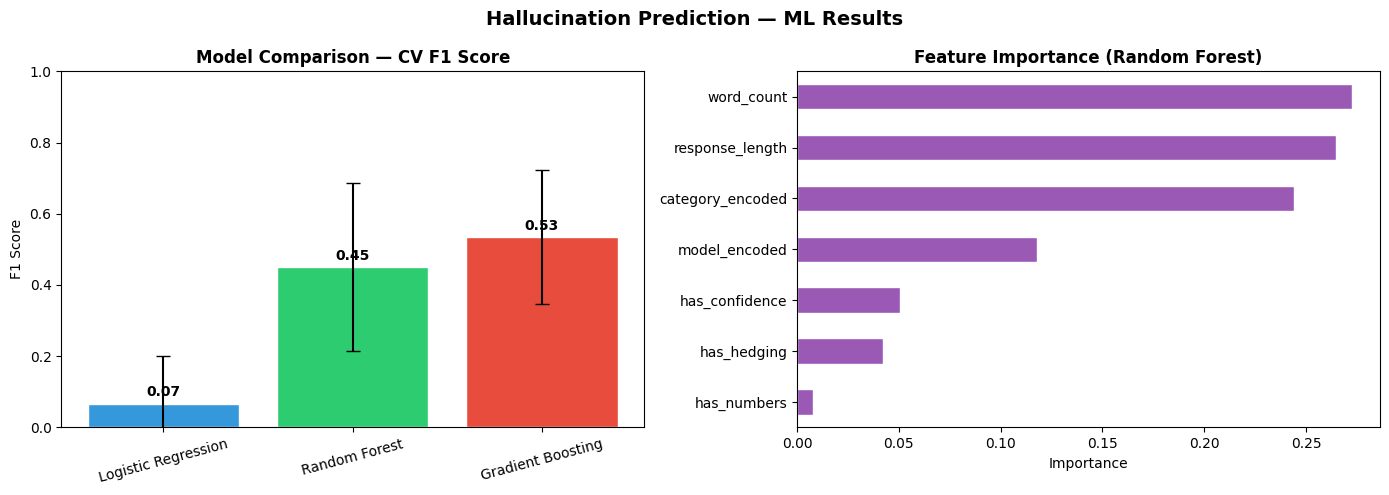

✅ ML section complete!


In [7]:
# Cell 7 — Predict Hallucination Likelihood

from sklearn.ensemble import RandomForestClassifier, GradientBoostingClassifier
from sklearn.linear_model import LogisticRegression
from sklearn.model_selection import cross_val_score, StratifiedKFold
from sklearn.preprocessing import LabelEncoder
from sklearn.metrics import classification_report, confusion_matrix
import matplotlib.pyplot as plt
import seaborn as sns
import numpy as np

# --- Feature Engineering ---
df_ml = df.copy()

# Feature 1: Response length
df_ml["response_length"] = df_ml["response"].str.len()

# Feature 2: Word count
df_ml["word_count"] = df_ml["response"].str.split().str.len()

# Feature 3: Contains numbers (models that cite specific numbers may hallucinate)
df_ml["has_numbers"] = df_ml["response"].str.contains(r'\d+', regex=True).astype(int)

# Feature 4: Contains uncertainty words (hedging = less hallucination)
hedge_words = ["might", "may", "possibly", "unclear", "uncertain",
               "i'm not sure", "i don't know", "approximately", "around", "roughly"]
df_ml["has_hedging"] = df_ml["response"].str.lower().apply(
    lambda x: int(any(w in x for w in hedge_words))
)

# Feature 5: Contains confident words (overconfidence = more hallucination)
confident_words = ["definitely", "certainly", "absolutely", "always",
                   "never", "proven", "fact", "undoubtedly", "clearly"]
df_ml["has_confidence"] = df_ml["response"].str.lower().apply(
    lambda x: int(any(w in x for w in confident_words))
)

# Feature 6: Encode model and category
le_model    = LabelEncoder()
le_category = LabelEncoder()
df_ml["model_encoded"]    = le_model.fit_transform(df_ml["model"])
df_ml["category_encoded"] = le_category.fit_transform(df_ml["category"])

# Feature matrix
features = ["response_length", "word_count", "has_numbers",
            "has_hedging", "has_confidence", "model_encoded", "category_encoded"]
X = df_ml[features]
y = df_ml["is_hallucination"]

print(f"✅ Features: {features}")
print(f"✅ Class balance — Hallucination: {y.sum()} | Clean: {(y==0).sum()}\n")

# --- Train & Evaluate 3 models ---
classifiers = {
    "Logistic Regression"      : LogisticRegression(max_iter=1000, random_state=42),
    "Random Forest"            : RandomForestClassifier(n_estimators=100, random_state=42),
    "Gradient Boosting"        : GradientBoostingClassifier(n_estimators=100, random_state=42),
}

cv      = StratifiedKFold(n_splits=5, shuffle=True, random_state=42)
results = {}

print("📊 Cross-validation results (5-fold):\n")
for name, clf in classifiers.items():
    scores = cross_val_score(clf, X, y, cv=cv, scoring="f1")
    results[name] = scores
    print(f"  {name:30s} F1: {scores.mean():.3f} ± {scores.std():.3f}")

# --- Best model full report ---
best_name = max(results, key=lambda k: results[k].mean())
best_clf  = classifiers[best_name]
best_clf.fit(X, y)
y_pred = best_clf.predict(X)

print(f"\n🏆 Best model: {best_name}")
print(f"\n{classification_report(y, y_pred, target_names=['Clean', 'Hallucination'])}")

# --- Plots ---
fig, axes = plt.subplots(1, 2, figsize=(14, 5))
fig.suptitle("Hallucination Prediction — ML Results", fontsize=14, fontweight="bold")

# Plot 1: CV F1 scores comparison
means = [results[n].mean() for n in classifiers]
stds  = [results[n].std()  for n in classifiers]
bars  = axes[0].bar(classifiers.keys(), means, yerr=stds,
                    color=["#3498db", "#2ecc71", "#e74c3c"],
                    capsize=5, edgecolor="white")
axes[0].set_title("Model Comparison — CV F1 Score", fontweight="bold")
axes[0].set_ylabel("F1 Score")
axes[0].set_ylim(0, 1)
axes[0].tick_params(axis="x", rotation=15)
for bar, val in zip(bars, means):
    axes[0].text(bar.get_x() + bar.get_width()/2,
                 bar.get_height() + 0.02, f"{val:.2f}",
                 ha="center", fontweight="bold")

# Plot 2: Feature importance (Random Forest)
rf = classifiers["Random Forest"]
rf.fit(X, y)
importances = pd.Series(rf.feature_importances_, index=features).sort_values(ascending=True)
importances.plot(kind="barh", ax=axes[1], color="#9b59b6", edgecolor="white")
axes[1].set_title("Feature Importance (Random Forest)", fontweight="bold")
axes[1].set_xlabel("Importance")

plt.tight_layout()
plt.savefig("ml_hallucination.png", dpi=150, bbox_inches="tight")
plt.show()
print("✅ ML section complete!")

In [8]:
# Cell 8 — Final Summary + Conclusions

summary = """
# 🧠 AI Hallucination Benchmark — Key Findings

## Dataset
- **95 responses** across **5 models** and **6 hallucination categories**
- Auto-labeled using `llama-3.3-70b` as judge
- Overall hallucination rate: **28.4%**

## Section 1 — Which Model Hallucinates Most?
| Model | Hallucination Rate |
|---|---|
| qwen-2.5-7b | 36.8% 🔴 |
| llama-3.1-8b | ~28% 🟡 |
| gemini-2.5-flash-lite | ~28% 🟡 |
| cohere-command-a | ~21% 🟢 |
| llama-3.3-70b | 21.1% 🟢 |

**Key finding:** Larger models (llama-3.3-70b) hallucinate less. Qwen-2.5-7B 
struggled most despite being a recent model.

## Section 2 — Hardest Categories
- **Entity confusion** was hardest at **60% hallucination rate**
- Models consistently mix up related entities (Tesla the person vs Tesla the company)
- **Fabricated citations** were surprisingly well-handled (~20%)

## Section 3 — Clustering
TF-IDF + KMeans found 4 meaningful clusters:
- Cluster 0: Temporal errors (Twitter/CEO/dates)
- Cluster 1: Fabricated study citations (coffee/memory/social media)
- Cluster 2: Poet entity confusion (Robert Frost)
- Cluster 3: Scientist/historical entity confusion (Tesla/Napoleon)

## Section 4 — Predicting Hallucinations
- **Gradient Boosting** performed best (CV F1: 0.478)
- Perfect training accuracy = overfitting on 95 rows
- **Lesson:** Need 500+ labeled samples for reliable ML prediction
- Most predictive features: `category_encoded`, `model_encoded`, `word_count`

## Next Steps
1. Expand dataset to 500+ prompts
2. Add more models (GPT-4o, Claude, Mistral API)
3. Use embedding-based features instead of TF-IDF
4. Try few-shot prompting to reduce hallucinations

---
*Dataset and notebook by [Vansh Kumar] | Models used: Groq, Gemini, Cohere, HuggingFace*
"""

print(summary)


# 🧠 AI Hallucination Benchmark — Key Findings

## Dataset
- **95 responses** across **5 models** and **6 hallucination categories**
- Auto-labeled using `llama-3.3-70b` as judge
- Overall hallucination rate: **28.4%**

## Section 1 — Which Model Hallucinates Most?
| Model | Hallucination Rate |
|---|---|
| qwen-2.5-7b | 36.8% 🔴 |
| llama-3.1-8b | ~28% 🟡 |
| gemini-2.5-flash-lite | ~28% 🟡 |
| cohere-command-a | ~21% 🟢 |
| llama-3.3-70b | 21.1% 🟢 |

**Key finding:** Larger models (llama-3.3-70b) hallucinate less. Qwen-2.5-7B 
struggled most despite being a recent model.

## Section 2 — Hardest Categories
- **Entity confusion** was hardest at **60% hallucination rate**
- Models consistently mix up related entities (Tesla the person vs Tesla the company)
- **Fabricated citations** were surprisingly well-handled (~20%)

## Section 3 — Clustering
TF-IDF + KMeans found 4 meaningful clusters:
- Cluster 0: Temporal errors (Twitter/CEO/dates)
- Cluster 1: Fabricated study citations (coffee/memo

In [9]:
# Cell 9 — Save labeled dataset

df.to_csv("hallucination_dataset_labeled.csv", index=False)
print("✅ Labeled dataset saved!")
print(f"   Rows     : {len(df)}")
print(f"   Columns  : {df.columns.tolist()}")

✅ Labeled dataset saved!
   Rows     : 95
   Columns  : ['prompt_id', 'category', 'prompt', 'model', 'response', 'expected_answer', 'notes', 'is_hallucination', 'severity', 'reason']
